<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 190.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 192.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 160.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 168.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 174.1 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2025-06-25 14:18:39--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  64.6MB/s    in 2.4s    

2025-06-25 14:18:42 (64.6 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


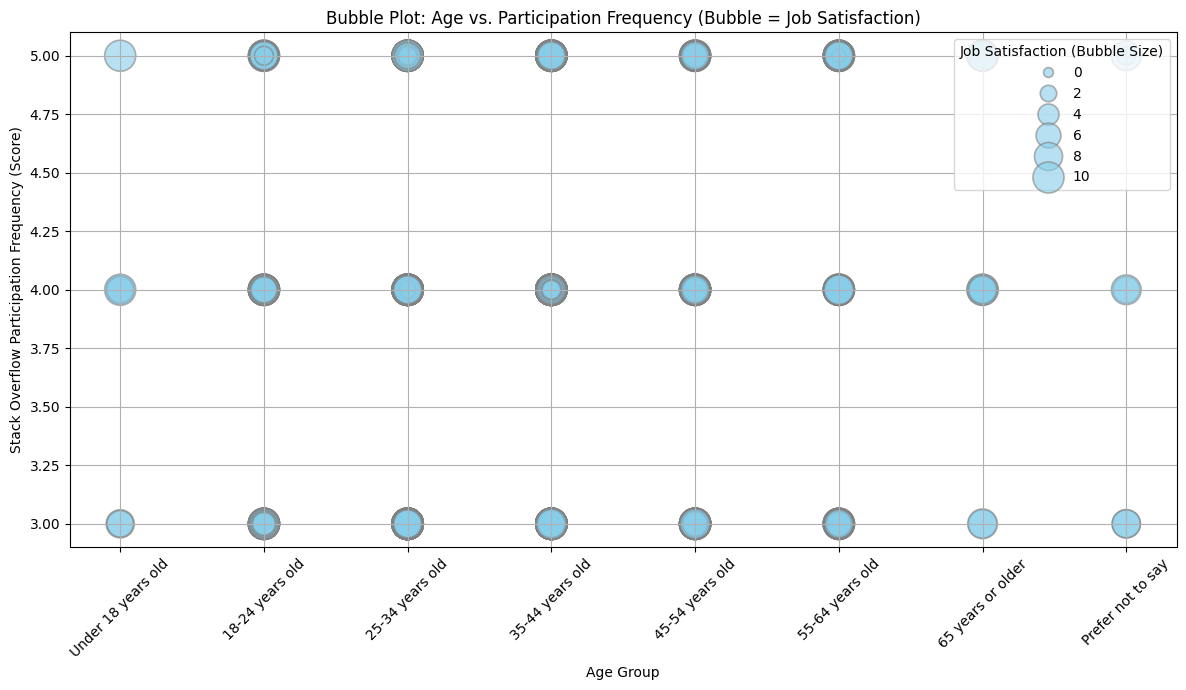

In [6]:
##Write your code here

!pip install seaborn
import seaborn as sns

df_plot = df[['Age', 'SOPartFreq', 'JobSat']].dropna()

df_plot['JobSat'] = pd.to_numeric(df_plot['JobSat'], errors='coerce')
df_plot = df_plot.dropna(subset=['JobSat'])

age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]
df_plot = df_plot[df_plot['Age'].isin(age_order)]
df_plot['Age'] = pd.Categorical(df_plot['Age'], categories=age_order, ordered=True)

freq_map = {
    'Multiple times per day': 5,
    'Daily or almost daily': 4,
    'A few times per week': 3,
    'A few times per month': 2,
    'Less than once per month': 1,
}
df_plot['SOPartFreqScore'] = df_plot['SOPartFreq'].map(freq_map)
df_plot = df_plot.dropna(subset=['SOPartFreqScore'])

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_plot,
    x='Age',
    y='SOPartFreqScore',
    size='JobSat',
    sizes=(50, 500),
    alpha=0.6,
    legend='brief',
    color='skyblue',
    edgecolor='gray'
)

plt.title('Bubble Plot: Age vs. Participation Frequency (Bubble = Job Satisfaction)')
plt.xlabel('Age Group')
plt.ylabel('Stack Overflow Participation Frequency (Score)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Job Satisfaction (Bubble Size)', loc='upper right')
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


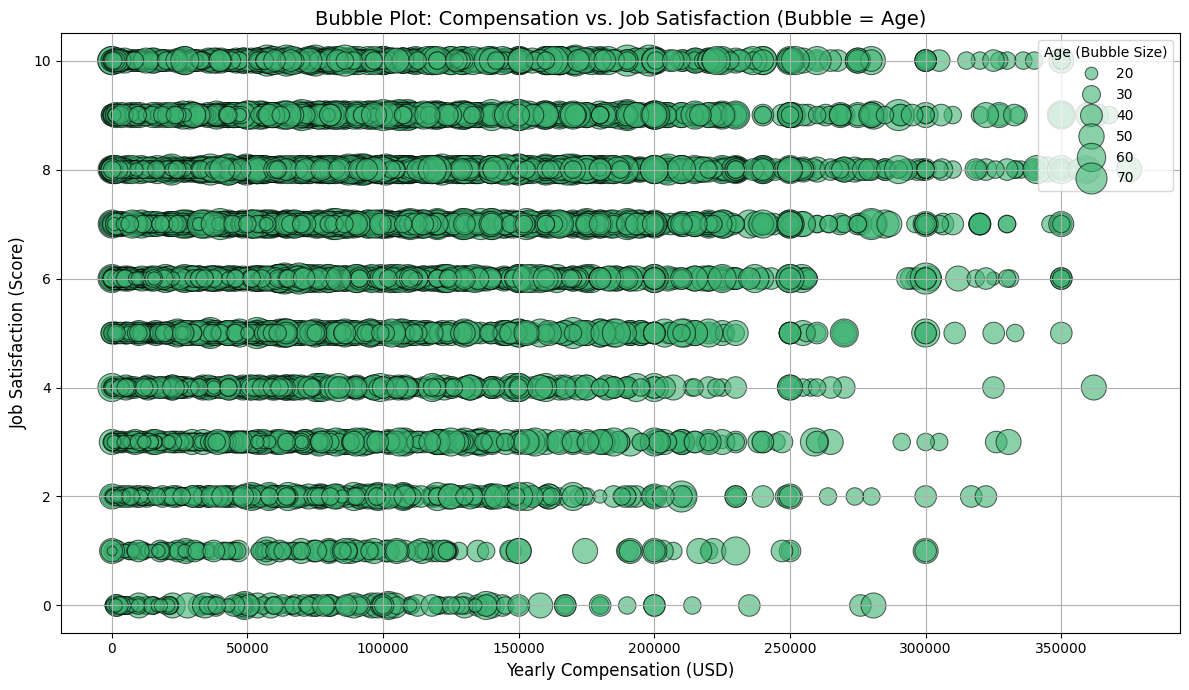

In [7]:
##Write your code here

# Filter relevant columns and remove rows with missing values
df_bubble = df[['ConvertedCompYearly', 'JobSat', 'Age']].dropna()

# Convert 'JobSat' to numeric if it's not already
df_bubble['JobSat'] = pd.to_numeric(df_bubble['JobSat'], errors='coerce')

# Map 'Age' categorical values to representative numeric midpoints
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}
df_bubble = df_bubble[df_bubble['Age'].isin(age_map.keys())]
df_bubble['AgeValue'] = df_bubble['Age'].map(age_map)

# Remove extreme compensation outliers (top 1%) for better visualization
df_bubble = df_bubble[df_bubble['ConvertedCompYearly'] < df_bubble['ConvertedCompYearly'].quantile(0.99)]

# Plot the bubble chart
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_bubble,
    x='ConvertedCompYearly',
    y='JobSat',
    size='AgeValue',
    sizes=(50, 500),
    alpha=0.6,
    color='mediumseagreen',
    edgecolor='black'
)

plt.title('Bubble Plot: Compensation vs. Job Satisfaction (Bubble = Age)', fontsize=14)
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction (Score)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Age (Bubble Size)', loc='upper right')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



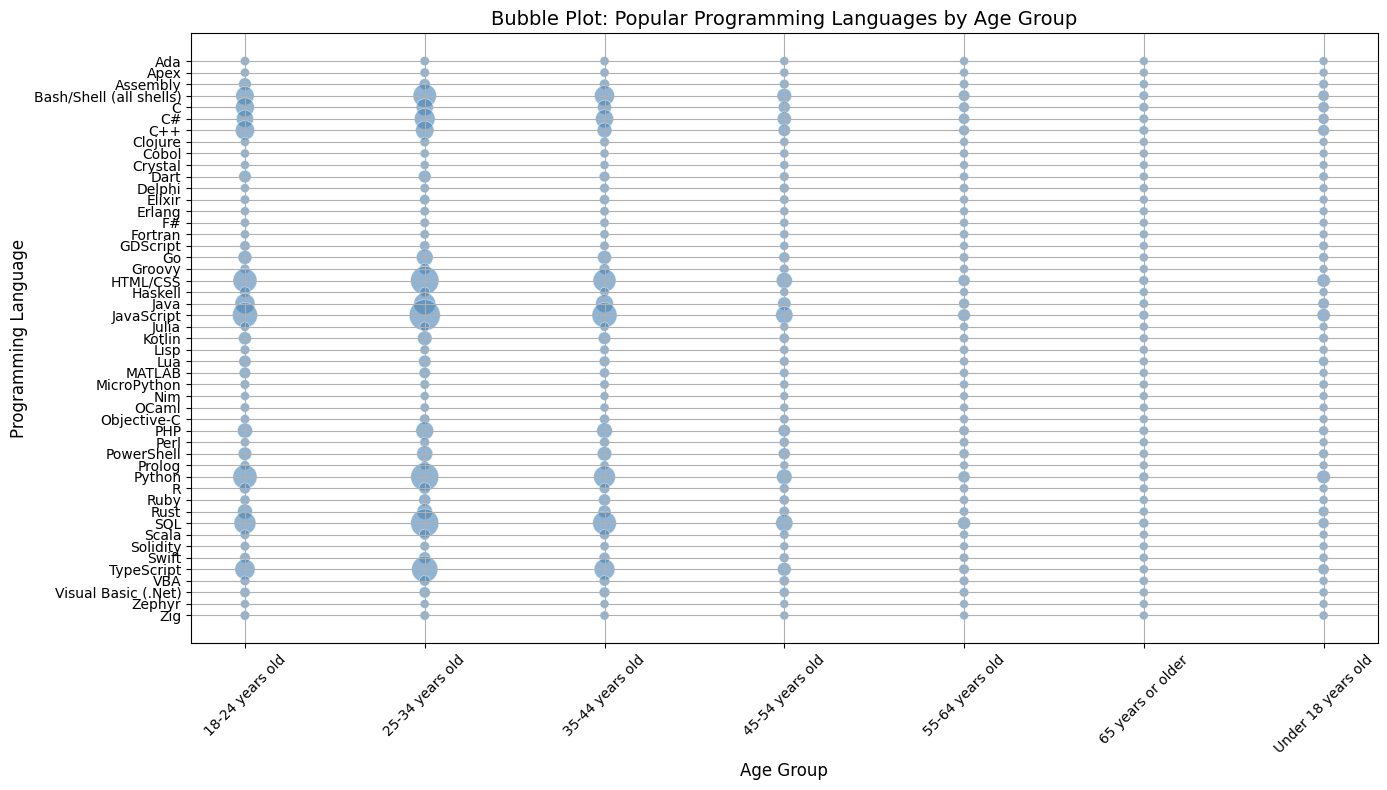

In [8]:
##Write your code here

# Filter relevant columns and drop rows with missing values
df_lang = df[['LanguageHaveWorkedWith', 'Age']].dropna()

# Flatten the data: split multiple languages and explode
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang = df_lang.explode('LanguageHaveWorkedWith')

# Filter valid age groups
valid_ages = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old',
    '65 years or older'
]
df_lang = df_lang[df_lang['Age'].isin(valid_ages)]

# Group by Age and Language, and count frequencies
lang_counts = df_lang.groupby(['Age', 'LanguageHaveWorkedWith']).size().reset_index(name='Frequency')

# Plot bubble chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=lang_counts,
    x='Age',
    y='LanguageHaveWorkedWith',
    size='Frequency',
    sizes=(40, 500),
    alpha=0.6,
    legend=False,
    color='steelblue'
)

plt.title('Bubble Plot: Popular Programming Languages by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


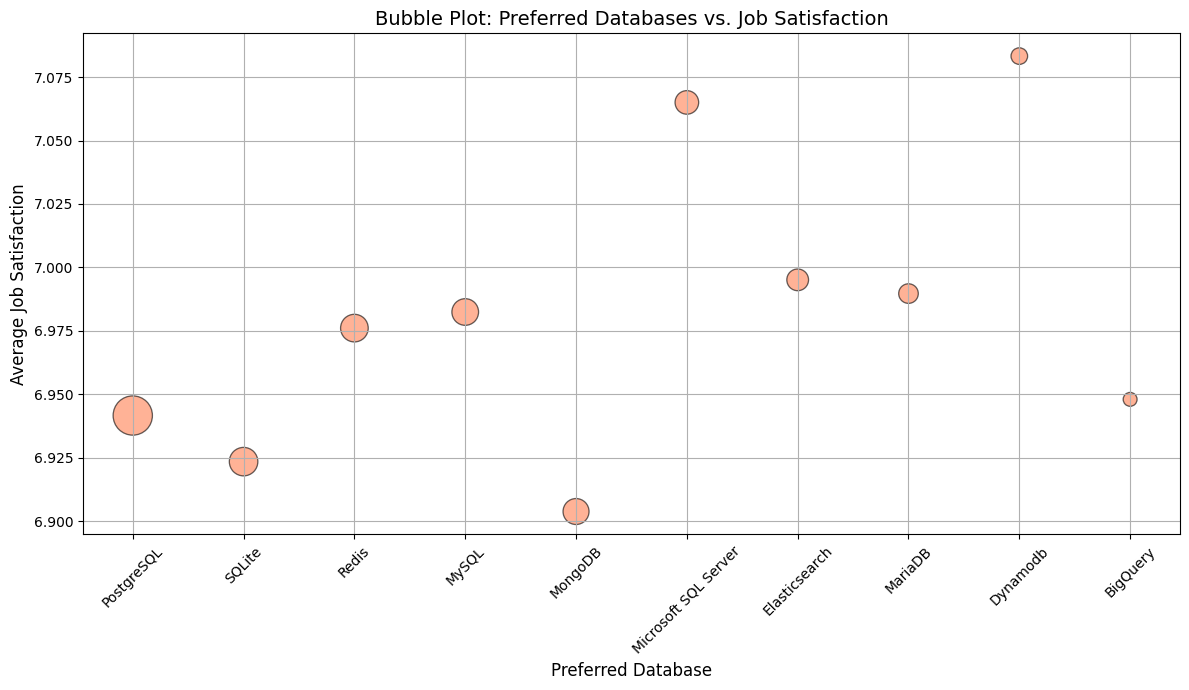

In [9]:
##Write your code here

# Filter relevant columns and drop missing values
df_db = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Split multiple databases and explode into rows
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.split(';')
df_db = df_db.explode('DatabaseWantToWorkWith')

# Remove rows with invalid or non-numeric JobSat
df_db['JobSat'] = pd.to_numeric(df_db['JobSat'], errors='coerce')
df_db = df_db.dropna(subset=['JobSat'])

# Group by Database and average JobSat, count respondents
db_stats = df_db.groupby('DatabaseWantToWorkWith').agg(
    AvgJobSat=('JobSat', 'mean'),
    Respondents=('JobSat', 'count')
).reset_index()

# Sort by respondent count and limit to top 10 for visibility
db_stats = db_stats.sort_values(by='Respondents', ascending=False).head(10)

# Plot the bubble chart
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=db_stats,
    x='DatabaseWantToWorkWith',
    y='AvgJobSat',
    size='Respondents',
    sizes=(100, 800),
    alpha=0.6,
    color='coral',
    edgecolor='black',
    legend=False
)

plt.title('Bubble Plot: Preferred Databases vs. Job Satisfaction', fontsize=14)
plt.xlabel('Preferred Database', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


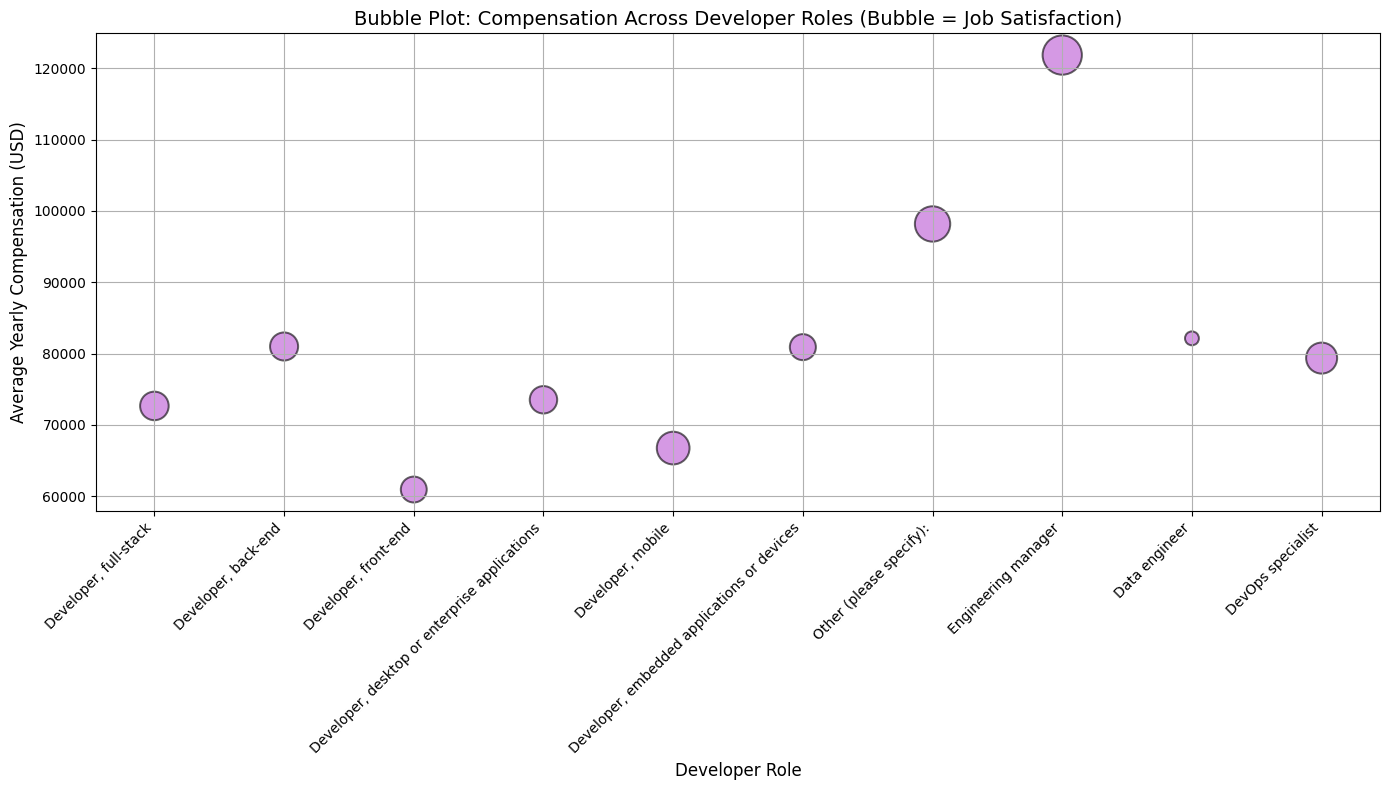

In [10]:
##Write your code here

# Filter relevant columns and drop rows with missing values
df_dev = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()

# Explode multiple developer roles
df_dev['DevType'] = df_dev['DevType'].str.split(';')
df_dev = df_dev.explode('DevType')

# Convert JobSat to numeric
df_dev['JobSat'] = pd.to_numeric(df_dev['JobSat'], errors='coerce')
df_dev = df_dev.dropna(subset=['JobSat'])

# Remove extreme compensation outliers (top 1%)
df_dev = df_dev[df_dev['ConvertedCompYearly'] < df_dev['ConvertedCompYearly'].quantile(0.99)]

# Group by DevType and calculate average compensation and job satisfaction
dev_stats = df_dev.groupby('DevType').agg(
    AvgComp=('ConvertedCompYearly', 'mean'),
    AvgJobSat=('JobSat', 'mean'),
    Respondents=('JobSat', 'count')
).reset_index()

# Take top 10 roles by respondent count
dev_stats = dev_stats.sort_values(by='Respondents', ascending=False).head(10)

# Plot the bubble chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=dev_stats,
    x='DevType',
    y='AvgComp',
    size='AvgJobSat',
    sizes=(100, 800),
    alpha=0.6,
    color='mediumorchid',
    edgecolor='black',
    legend=False
)

plt.title('Bubble Plot: Compensation Across Developer Roles (Bubble = Job Satisfaction)', fontsize=14)
plt.xlabel('Developer Role', fontsize=12)
plt.ylabel('Average Yearly Compensation (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


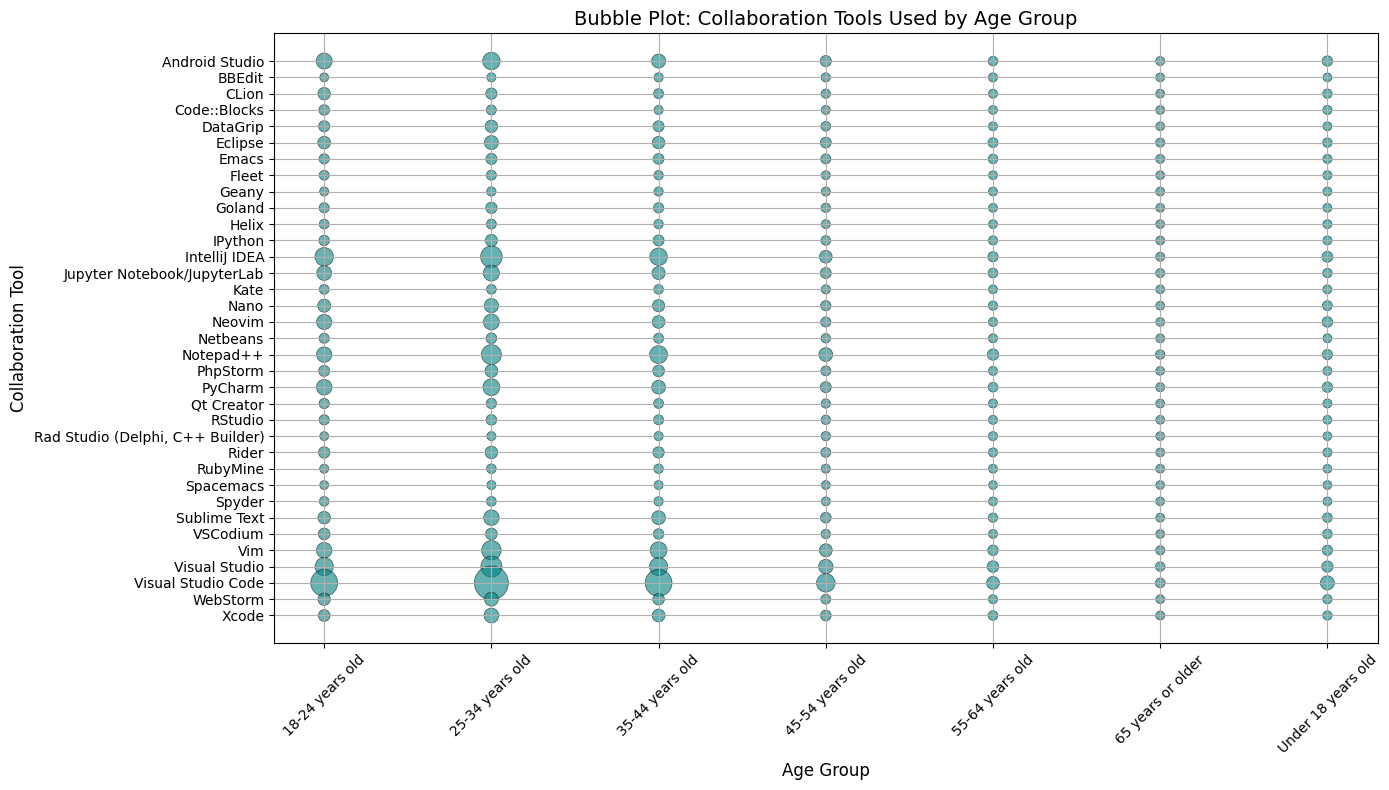

In [11]:
##Write your code here

# Filter relevant columns and drop rows with missing values
df_tools = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna()

# Explode multiple tools into separate rows
df_tools['NEWCollabToolsHaveWorkedWith'] = df_tools['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_tools = df_tools.explode('NEWCollabToolsHaveWorkedWith')

# Define valid age groups
valid_ages = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old',
    '65 years or older'
]
df_tools = df_tools[df_tools['Age'].isin(valid_ages)]

# Group by Age and Tool, count occurrences
tool_counts = df_tools.groupby(['Age', 'NEWCollabToolsHaveWorkedWith']).size().reset_index(name='Frequency')

# Plot the bubble chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=tool_counts,
    x='Age',
    y='NEWCollabToolsHaveWorkedWith',
    size='Frequency',
    sizes=(40, 600),
    alpha=0.6,
    color='teal',
    edgecolor='black',
    legend=False
)

plt.title('Bubble Plot: Collaboration Tools Used by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Collaboration Tool', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



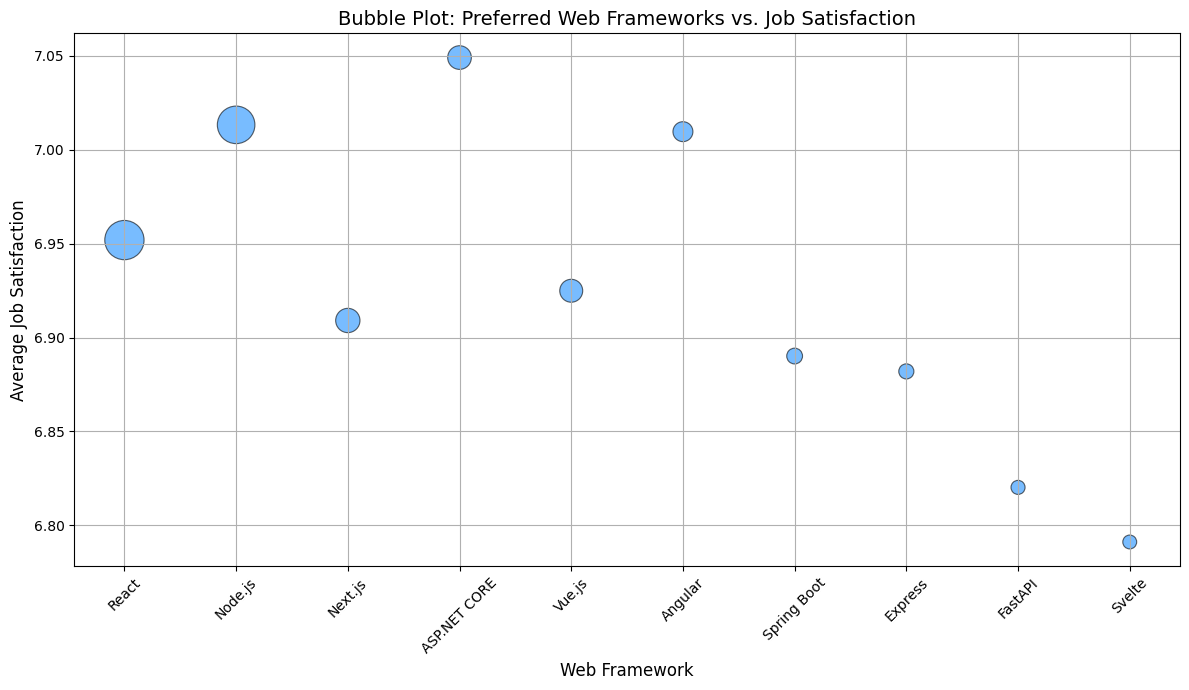

In [12]:
##Write your code here

# Filter relevant columns and drop rows with missing values
df_web = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# Split multiple frameworks and explode into rows
df_web['WebframeWantToWorkWith'] = df_web['WebframeWantToWorkWith'].str.split(';')
df_web = df_web.explode('WebframeWantToWorkWith')

# Convert JobSat to numeric
df_web['JobSat'] = pd.to_numeric(df_web['JobSat'], errors='coerce')
df_web = df_web.dropna(subset=['JobSat'])

# Group by framework and compute average JobSat and count of respondents
web_stats = df_web.groupby('WebframeWantToWorkWith').agg(
    AvgJobSat=('JobSat', 'mean'),
    Respondents=('JobSat', 'count')
).reset_index()

# Select top 10 frameworks by respondent count
web_stats = web_stats.sort_values(by='Respondents', ascending=False).head(10)

# Plot the bubble chart
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=web_stats,
    x='WebframeWantToWorkWith',
    y='AvgJobSat',
    size='Respondents',
    sizes=(100, 800),
    alpha=0.6,
    color='dodgerblue',
    edgecolor='black',
    legend=False
)

plt.title('Bubble Plot: Preferred Web Frameworks vs. Job Satisfaction', fontsize=14)
plt.xlabel('Web Framework', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



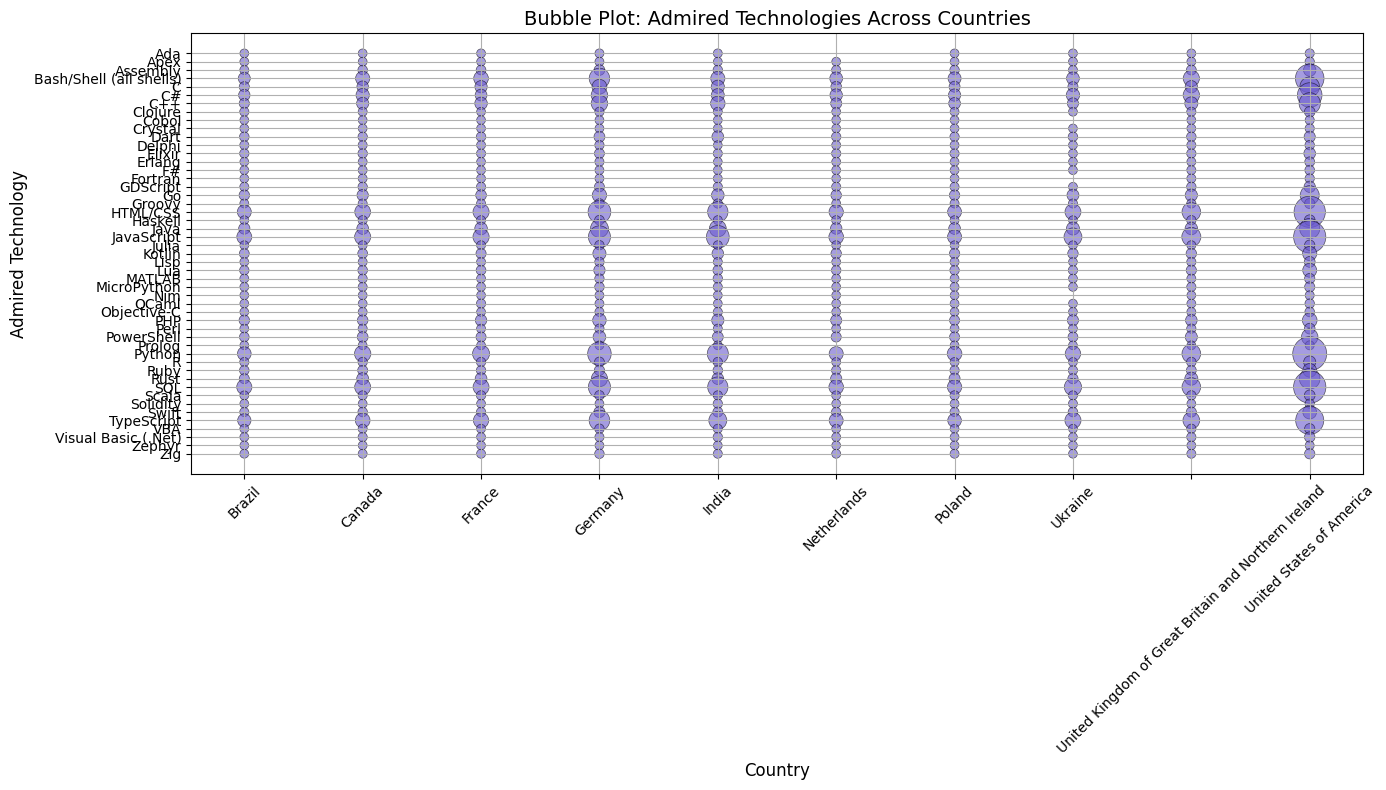

In [13]:
##Write your code here

# Filter relevant columns and drop rows with missing values
df_admired = df[['LanguageAdmired', 'Country']].dropna()

# Split multiple admired technologies and explode into rows
df_admired['LanguageAdmired'] = df_admired['LanguageAdmired'].str.split(';')
df_admired = df_admired.explode('LanguageAdmired')

# Group by Country and LanguageAdmired, count occurrences
admired_counts = df_admired.groupby(['Country', 'LanguageAdmired']).size().reset_index(name='Frequency')

# Filter for top 10 countries by total frequency for clarity
top_countries = admired_counts.groupby('Country')['Frequency'].sum().nlargest(10).index
admired_counts = admired_counts[admired_counts['Country'].isin(top_countries)]

# Plot the bubble chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=admired_counts,
    x='Country',
    y='LanguageAdmired',
    size='Frequency',
    sizes=(40, 600),
    alpha=0.6,
    color='slateblue',
    edgecolor='black',
    legend=False
)

plt.title('Bubble Plot: Admired Technologies Across Countries', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Admired Technology', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
